In [1]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [5]:
y_scores = model.predict_proba(X_test)[:, 1]

y_scores

array([0.2758698 , 0.18843781, 0.11448335, 0.16354256, 0.47152382,
       0.44181378, 0.01545858, 0.66077384, 0.54146156, 0.77732996,
       0.25591852, 0.89734396, 0.33619742, 0.3030328 , 0.08197907,
       0.38092474, 0.13935112, 0.0747936 , 0.8667417 , 0.5614278 ,
       0.2084072 , 0.07739223, 0.53963343, 0.09458139, 0.53950235,
       0.88554956, 0.12431156, 0.0301613 , 0.25152596, 0.11581091,
       0.91113266, 0.87075878, 0.76536338, 0.83753237, 0.6166828 ,
       0.68329681, 0.96813236, 0.24363452, 0.51147768, 0.73613319,
       0.0698326 , 0.59412031, 0.58366902, 0.32718608, 0.02758992,
       0.50239527, 0.63935312, 0.22533661, 0.36056019, 0.95629663,
       0.04889434, 0.6609671 , 0.81168271, 0.24552402, 0.09325442,
       0.04151937, 0.77816465, 0.00570348, 0.40861835, 0.75696035,
       0.74135346, 0.35193953, 0.19236342, 0.2049207 , 0.07687963,
       0.62716809, 0.05091408, 0.73285998, 0.03691782, 0.71593619,
       0.6752412 , 0.07016267, 0.18114703, 0.11429924, 0.09115

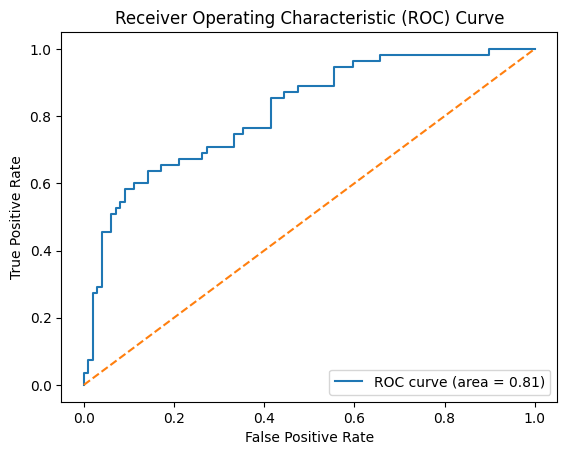

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

plt.show()